### CIFAR10

In [1]:
import tensorflow as tensorflow
import keras
import pandas
import numpy
from sklearn.model_selection import train_test_split

In [3]:
#import dataset
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [6]:

from functools import partial


RegularizedDense = partial(
    keras.layers.Dense,
    activation="elu",
    kernel_initializer="he_normal",
    kernel_regularizer=keras.regularizers.l2(0.01),
)

#build a DNN with 20 hidden layers 

model = keras.models.Sequential([
     keras.layers.Flatten(input_shape=(32,32,3)),

        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        RegularizedDense(100),
        keras.layers.Dense(10, activation="softmax")
])




c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
#callbacks
import os
from utils.run_lodgir import get_run_logdir
from datetime import datetime

root_logdir = os.path.join(os.curdir , "my_logs")
run_logdir = os.path.join(root_logdir, datetime.now().strftime("%Y%m%d-%H%M%S"))

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor ='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.001
)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5" , save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir=run_logdir,
    histogram_freq=1,
    profile_batch='10,15'
) 

In [10]:
optimizer= keras.optimizers.Nadam(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
# only add TensorBoard callback if tensorboard is available
try:
    import tensorboard  # check if tensorboard package is installed
    use_tb = True
except Exception:
    use_tb = False

callbacks = [reduce_lr_cb, early_stopping_cb, checkpoint_cb]
if use_tb:
    callbacks.append(tensorboard_cb)

history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test), callbacks=callbacks)
mse = model.evaluate(x_test, y_test)
print("MSE: ", mse)


Epoch 1/20
1553/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1864 - loss: 40.6582

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.2325 - loss: 27.9183 - val_accuracy: 0.3159 - val_loss: 20.9258 - learning_rate: 0.0010
Epoch 2/20
1554/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3004 - loss: 19.6663

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3170 - loss: 18.3974 - val_accuracy: 0.3500 - val_loss: 15.9465 - learning_rate: 0.0010
Epoch 3/20
1554/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3502 - loss: 14.8046

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3563 - loss: 13.6545 - val_accuracy: 0.3292 - val_loss: 11.5317 - learning_rate: 0.0010
Epoch 4/20
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3715 - loss: 10.3477

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3699 - loss: 9.3376 - val_accuracy: 0.3270 - val_loss: 7.4953 - learning_rate: 0.0010
Epoch 5/20
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3686 - loss: 6.5850

...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3495 - loss: 3.6556 - val_accuracy: 0.3677 - val_loss: 2.9426 - learning_rate: 0.0010
Epoch 7/20
1554/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3262 - loss: 2.8249

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3234 - loss: 2.6759 - val_accuracy: 0.3030 - val_loss: 2.4768 - learning_rate: 0.0010
Epoch 8/20
1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3193 - loss: 2.4067

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3115 - loss: 2.3724 - val_accuracy: 0.3135 - val_loss: 2.2782 - learning_rate: 0.0010
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3114 - loss: 2.2767

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3103 - loss: 2.2670 - val_accuracy: 0.3175 - val_loss: 2.2146 - learning_rate: 0.0010
Epoch 10/20
1552/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3071 - loss: 2.2471

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3094 - loss: 2.2371 - val_accuracy: 0.3154 - val_loss: 2.1976 - learning_rate: 0.0010
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3113 - loss: 2.2244 - val_accuracy: 0.2777 - val_loss: 2.2715 - learning_rate: 0.0010
Epoch 12/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3103 - loss: 2.2169 - val_accuracy: 0.2884 - val_loss: 2.2483 - learning_rate: 0.0010
Epoch 13/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3132 - loss: 2.2129 - val_accuracy: 0.2813 - val_loss: 2.2963 - learning_rate: 0.0010
Epoch 14/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3145 - loss: 2.2013 - val_accuracy: 0.2650 - val_loss: 2.3104 - learning_rate: 0.0010
Epoch 15/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3171 - loss: 2.1948 - val_accuracy: 0.3008 - val_loss: 2.2353 - learning_rate: 0.0010
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3154 - loss: 2.1976
MSE:  [

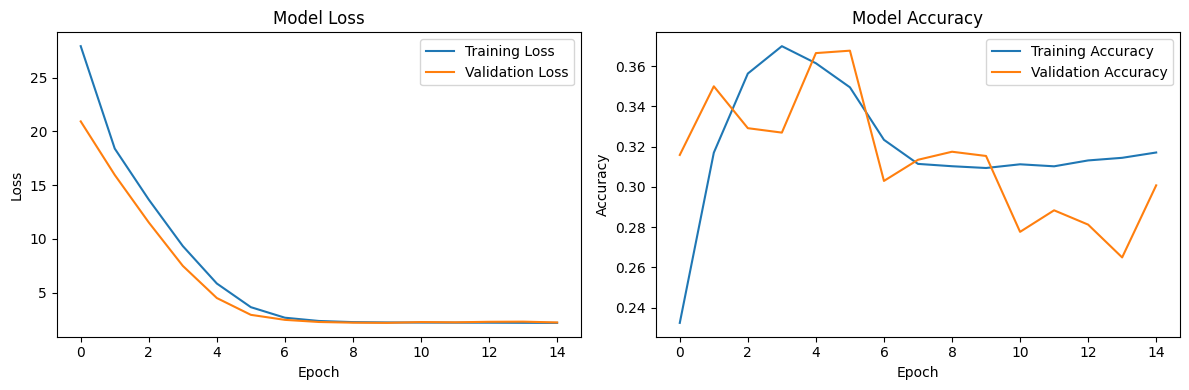

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusiones

- El modelo si aprende, pero el rendimiento final es bajo: la mejor validacion llego a ~36.8% en el epoch 6 y termino alrededor de 30.1%.
- Las perdidas se quedan cerca de 2.2, muy proximas al baseline de azar para 10 clases, asi que la red no esta separando bien las clases.
- No se aprecia sobreajuste fuerte; train y validation van bastante pegados. El problema parece ser mas de capacidad/representacion que de regularizacion.
- Para CIFAR-10 conviene normalizar los datos y usar una CNN en lugar de una MLP densa sobre pixeles crudos.

#### Try adding Batch Normalization 

In [15]:
capas = [
    keras.layers.Flatten(input_shape=(32, 32, 3)) # Capa de entrada
]

# Añadimos las 20 capas ocultas con su respectiva normalización en un bucle
for _ in range(20):
    capas.append(RegularizedDense(100))
    capas.append(keras.layers.BatchNormalization())

# Añadimos la capa de salida al final
capas.append(keras.layers.Dense(10, activation="softmax", kernel_initializer="glorot_uniform"))

# Empaquetamos todo en el modelo
model_batch = keras.models.Sequential(capas)

c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001)
model_batch.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history_batch = model_batch.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test), callbacks=callbacks)
mse_batch = model_batch.evaluate(x_test, y_test)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.2778 - loss: 11.8712 - val_accuracy: 0.1530 - val_loss: 2.7162 - learning_rate: 0.0010
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2305 - loss: 2.2163 - val_accuracy: 0.1026 - val_loss: 2.6400 - learning_rate: 0.0010
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1910 - loss: 2.2417 - val_accuracy: 0.1000 - val_loss: 2.5486 - learning_rate: 0.0010
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1815 - loss: 2.3448 - val_accuracy: 0.1000 - val_loss: 2.5933 - learning_rate: 0.0010
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1870 - loss: 2.2337 - val_accuracy: 0.1000 - val_loss: 2.4449 - learning_rate: 0.0010
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1530 - loss: 2.7162


## Conclusiones del modelo batch

- El modelo batch entreno solo 5 epochs antes de detenerse.
- Su accuracy final fue 18.7% en entrenamiento y 10.0% en validacion.
- La mejor val_accuracy fue 15.3%, asi que BatchNormalization no mejoro el rendimiento en esta configuracion.
- La perdida final de validacion quedo en 2.4449, peor que la del modelo original.

## Comparacion: model vs model_batch

- Model original: mejor val_accuracy de 36.8%, accuracy de evaluacion de 31.5% y val_loss final de 2.2353.
- Model batch: mejor val_accuracy de 15.3%, accuracy de evaluacion de 15.3% y val_loss final de 2.4449.
- Conclusion: el modelo original es claramente mejor; el modelo batch empeora bastante y no compensa cambiar solo BatchNormalization sin revisar el preprocesado y la arquitectura.

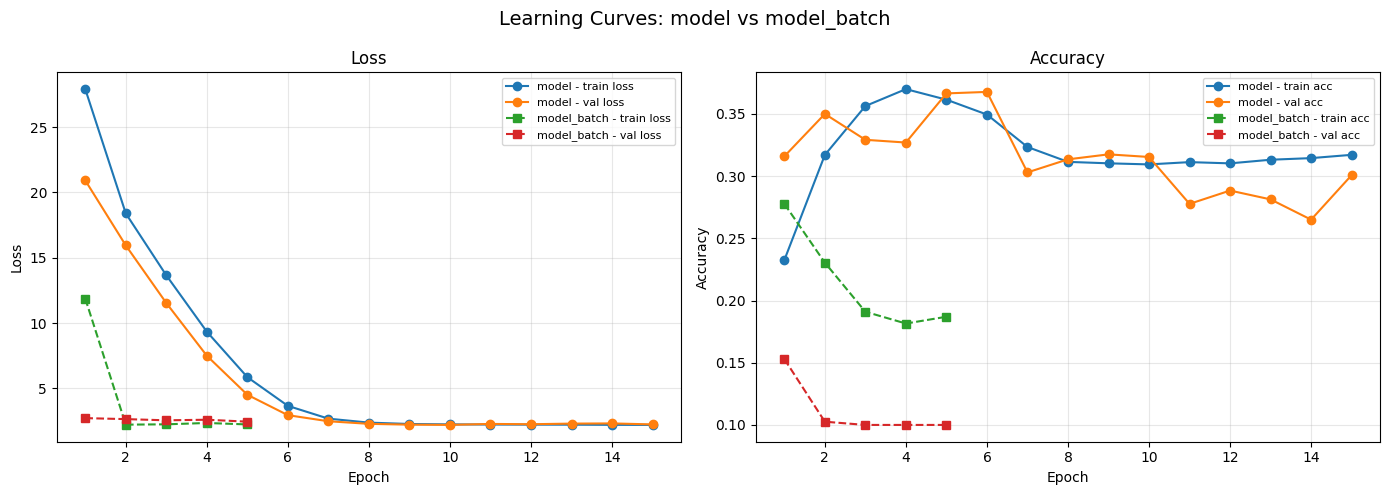

In [19]:
import matplotlib.pyplot as plt

epochs_model = range(1, len(history.history["loss"]) + 1)
epochs_batch = range(1, len(history_batch.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curves: model vs model_batch", fontsize=14)

axes[0].plot(epochs_model, history.history["loss"], marker="o", label="model - train loss")
axes[0].plot(epochs_model, history.history["val_loss"], marker="o", label="model - val loss")
axes[0].plot(epochs_batch, history_batch.history["loss"], marker="s", linestyle="--", label="model_batch - train loss")
axes[0].plot(epochs_batch, history_batch.history["val_loss"], marker="s", linestyle="--", label="model_batch - val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(epochs_model, history.history["accuracy"], marker="o", label="model - train acc")
axes[1].plot(epochs_model, history.history["val_accuracy"], marker="o", label="model - val acc")
axes[1].plot(epochs_batch, history_batch.history["accuracy"], marker="s", linestyle="--", label="model_batch - train acc")
axes[1].plot(epochs_batch, history_batch.history["val_accuracy"], marker="s", linestyle="--", label="model_batch - val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Try replacing Batch Normalization with SELU

In [22]:
RegularizedDense = partial(
    keras.layers.Dense,
    activation="selu",                   # Reemplazamos ELU por SELU
    kernel_initializer="lecun_normal",   # Reemplazamos He por LeCun (Obligatorio)
    kernel_regularizer=keras.regularizers.l2(0.01) 
)


capa_normalizacion = keras.layers.Normalization()


capas = [
    capa_normalizacion ,
    keras.layers.Flatten(input_shape=(32, 32, 3))
     # Estandariza la entrada automáticamente
]

# Añadimos las 20 capas ocultas
for _ in range(20):
    capas.append(RegularizedDense(100))
    
# Capa de salida (Softmax sigue requiriendo Glorot)
capas.append(keras.layers.Dense(10, activation="softmax", kernel_initializer="glorot_uniform"))

modelo_selu = keras.models.Sequential(capas)

c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
# Adaptamos la capa de normalización a tus datos reales
capa_normalizacion.adapt(x_train)
modelo_selu.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer=keras.optimizers.Nadam(learning_rate=0.001), 
    metrics=["accuracy"]
)
historial_selu = modelo_selu.fit(
    x_train,
    y_train,
    epochs=20,
    validation_data=(x_test, y_test),
        callbacks=callbacks
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2777 - loss: 2.0808

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2795 - loss: 2.0828 - val_accuracy: 0.2884 - val_loss: 2.0814 - learning_rate: 0.0010
Epoch 2/20
1556/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2829 - loss: 2.0843

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2825 - loss: 2.0787 - val_accuracy: 0.2783 - val_loss: 2.0774 - learning_rate: 0.0010
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2788 - loss: 2.0830 - val_accuracy: 0.2699 - val_loss: 2.0942 - learning_rate: 0.0010
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2810 - loss: 2.0804 - val_accuracy: 0.2805 - val_loss: 2.0804 - learning_rate: 0.0010
Epoch 5/20
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2809 - loss: 2.0759

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2797 - loss: 2.0788 - val_accuracy: 0.2731 - val_loss: 2.0630 - learning_rate: 0.0010
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2807 - loss: 2.0806 - val_accuracy: 0.2748 - val_loss: 2.0654 - learning_rate: 0.0010
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2822 - loss: 2.0794 - val_accuracy: 0.2833 - val_loss: 2.0752 - learning_rate: 0.0010
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2835 - loss: 2.0745 - val_accuracy: 0.2699 - val_loss: 2.0993 - learning_rate: 0.0010
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2791 - loss: 2.0786 - val_accuracy: 0.2828 - val_loss: 2.1010 - learning_rate: 0.0010
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2827 - loss: 2.0773 - val_accuracy: 0.2664 - val_loss: 2.0859 - learning_rate: 0.0010


#### Regularized with alpha dropout

In [30]:
RegularizedDense = partial(
    keras.layers.Dense,
    activation="selu",
    kernel_initializer="lecun_normal"
)

# 2. Construimos la red
capa_normalizacion = keras.layers.Normalization(input_shape=(32, 32, 3))
capas = [capa_normalizacion, keras.layers.Flatten()]

for _ in range(20):
    capas.append(RegularizedDense(100))
    # ¡Aquí entra el Alpha Dropout! Tasa baja del 10%
    capas.append(keras.layers.AlphaDropout(rate=0.1))

capas.append(keras.layers.Dense(10, activation="softmax", kernel_initializer="glorot_uniform"))

modelo_snn = keras.models.Sequential(capas)

# Entrenamos el modelo normalmente
capa_normalizacion.adapt(x_train)
modelo_snn.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
historial = modelo_snn.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test), callbacks=callbacks)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.1780 - loss: 2.1553 - val_accuracy: 0.2182 - val_loss: 4.5345 - learning_rate: 0.0010
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2358 - loss: 1.9809 - val_accuracy: 0.1948 - val_loss: 10.3689 - learning_rate: 0.0010
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.2409 - loss: 1.9623 - val_accuracy: 0.2560 - val_loss: 5.7312 - learning_rate: 0.0010
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2359 - loss: 1.9883 - val_accuracy: 0.2544 - val_loss: 5.4923 - learning_rate: 0.0010
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.2465 - loss: 1.9376 - val_accuracy: 0.2574 - val_loss: 6.2776 - learning_rate: 0.0010


### Add AlphaDropout 

In [31]:
import numpy as np
# Hacemos 100 predicciones completas sobre el set de prueba forzando el Dropout
# Nota: Llamar a modelo_snn(x_test) como si fuera una función es más rápido que .predict()
predicciones_mc = [modelo_snn(x_test, training=True) for _ in range(100)]

# predicciones_mc es una lista de 100 arrays de probabilidades.
# Los apilamos y calculamos la probabilidad promedio matemática para cada imagen
probabilidades_promedio = np.mean(predicciones_mc, axis=0)

# Obtenemos la clase ganadora final (la de mayor probabilidad promedio)
clases_predichas_mc = np.argmax(probabilidades_promedio, axis=1)

# Calculamos la precisión final comparando contra las etiquetas reales (y_test)
# Asumiendo que y_test tiene la forma (N,)
precision_mc = np.mean(clases_predichas_mc == y_test)

print(f"Precisión lograda con MC Dropout: {precision_mc * 100:.2f}%")

Precisión lograda con MC Dropout: 10.00%


## Conclusiones del bloque SELU

- SELU fue el mejor de este bloque: alcanzó una mejor val_accuracy de 28.84% en el epoch 1 y terminó con 26.64% de validación.
- El entrenamiento fue estable, con una loss final de 2.0773 y val_loss de 2.0859, pero el aprendizaje real siguió siendo limitado.
- AlphaDropout no ayudó en esta configuración: llegó a 25.74% de val_accuracy, con una val_loss muy alta de 6.2776, señal de que la regularización fue demasiado agresiva o mal alineada con el resto de la arquitectura.
- MC Dropout no mejoró la precisión: quedó en 10.0%, prácticamente azar.

## Comparación entre modelos

- Modelo original con ELU y regularización L2: fue el más sólido de todos, con mejor val_accuracy de 36.84% y accuracy de evaluación de 31.54%.
- Modelo batch con BatchNormalization: fue peor que el original, con mejor val_accuracy de 15.30% y accuracy de evaluación de 15.30%.
- Modelo SELU: quedó por debajo del modelo original, pero por encima de AlphaDropout y MC Dropout.
- Conclusión general: en este problema, cambiar la activación o añadir regularizaciones más sofisticadas no compensa la falta de una arquitectura adecuada para CIFAR-10; la mejora real vendrá de normalizar bien los datos y pasar a una CNN.

### Try use 1 cycle scheduling

In [43]:
import math
from callbacks import OneCycleScheduler

# 1. Definimos los parámetros del entrenamiento
batch_size = 128
epochs = 5 # Reducimos para que el experimento termine dentro de esta sesión

# 2. Calculamos los pasos totales (Iteraciones)
# math.ceil redondea hacia arriba por si el último lote está incompleto
pasos_por_epoca = math.ceil(len(x_train) / batch_size)
iteraciones_totales = epochs * pasos_por_epoca

# 3. Instanciamos el Scheduler
# Nota: Usamos un max_rate conservador para evitar inestabilidad.
# usarías el "LR Finder" para descubrir este número mágico exacto.
scheduler_1cycle = OneCycleScheduler.OneCycleScheduler(
    iterations=iteraciones_totales,
    max_rate=0.01
)

In [44]:
import importlib
from callbacks import OneCycleScheduler as OneCycleSchedulerModule
importlib.reload(OneCycleSchedulerModule)

scheduler_1cycle = OneCycleSchedulerModule.OneCycleScheduler(
    iterations=iteraciones_totales,
    max_rate=0.01
)

modelo_snn.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer=keras.optimizers.Nadam(), 
    metrics=["accuracy"]
)

print("Iniciando entrenamiento con 1Cycle Scheduling...")


historial_1cycle = modelo_snn.fit(
    x_train, y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(x_test, y_test),
    callbacks=[callbacks , scheduler_1cycle] # Inyectamos el controlador aquí
)

Iniciando entrenamiento con 1Cycle Scheduling...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1007 - loss: 2.4936 - val_accuracy: 0.1000 - val_loss: 9.1698 - learning_rate: 0.0050
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0994 - loss: 2.3296 - val_accuracy: 0.1000 - val_loss: 9.0761 - learning_rate: 0.0090
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1002 - loss: 2.3337 - val_accuracy: 0.1000 - val_loss: 10.0208 - learning_rate: 0.0070
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0986 - loss: 2.3226 - val_accuracy: 0.1000 - val_loss: 9.1301 - learning_rate: 0.0030
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1020 - loss: 2.3091 - val_accuracy: 0.1000 - val_loss: 9.1201 - learning_rate: 6.0711e-06


## Conclusiones del 1Cycle Scheduling

- El esquema 1Cycle no mejoro el modelo; con esta configuracion se comporto de forma inestable y termino muy mal.
- La accuracy de entrenamiento se quedo alrededor de 10%, es decir, cerca del azar para 10 clases.
- La val_accuracy tambien se mantuvo en 10%, mientras que la val_loss subio mucho, llegando a valores cercanos a 9-10.
- Esto sugiere que el max_rate y/o la arquitectura actual son demasiado agresivos para este modelo; el scheduler funciono tecnicamente, pero la configuracion no fue buena.
- En comparacion con los otros experimentos, 1Cycle es el peor resultado hasta ahora y no compensa sin ajustar mejor el learning rate, la arquitectura o el preprocesado.

In [45]:
import pandas as pd
from IPython.display import display

def pct(value):
    return f"{float(value) * 100:.2f}%"

tabla_final = pd.DataFrame([
    {
        "Modelo": "ELU + L2",
        "Epocas": len(history.history["loss"]),
        "Train acc final": pct(history.history["accuracy"][-1]),
        "Mejor val_acc": pct(max(history.history["val_accuracy"])),
        "Val_acc final": pct(history.history["val_accuracy"][-1]),
        "Val_loss final": f"{history.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": pct(mse[1]),
        "Nota": "Mejor balance general",
    },
    {
        "Modelo": "BatchNorm + ELU + L2",
        "Epocas": len(history_batch.history["loss"]),
        "Train acc final": pct(history_batch.history["accuracy"][-1]),
        "Mejor val_acc": pct(max(history_batch.history["val_accuracy"])),
        "Val_acc final": pct(history_batch.history["val_accuracy"][-1]),
        "Val_loss final": f"{history_batch.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": pct(mse_batch[1]),
        "Nota": "Peor que el original",
    },
    {
        "Modelo": "SELU + Normalization",
        "Epocas": len(historial_selu.history["loss"]),
        "Train acc final": pct(historial_selu.history["accuracy"][-1]),
        "Mejor val_acc": pct(max(historial_selu.history["val_accuracy"])),
        "Val_acc final": pct(historial_selu.history["val_accuracy"][-1]),
        "Val_loss final": f"{historial_selu.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": "—",
        "Nota": "Estable, pero limitado",
    },
    {
        "Modelo": "SELU + AlphaDropout",
        "Epocas": len(historial.history["loss"]),
        "Train acc final": pct(historial.history["accuracy"][-1]),
        "Mejor val_acc": pct(max(historial.history["val_accuracy"])),
        "Val_acc final": pct(historial.history["val_accuracy"][-1]),
        "Val_loss final": f"{historial.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": "—",
        "Nota": "Se degrada mucho en validacion",
    },
    {
        "Modelo": "1Cycle sobre modelo_snn",
        "Epocas": len(historial_1cycle.history["loss"]),
        "Train acc final": pct(historial_1cycle.history["accuracy"][-1]),
        "Mejor val_acc": pct(max(historial_1cycle.history["val_accuracy"])),
        "Val_acc final": pct(historial_1cycle.history["val_accuracy"][-1]),
        "Val_loss final": f"{historial_1cycle.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": "—",
        "Nota": "Muy inestable",
    },
    {
        "Modelo": "MC Dropout sobre modelo_snn",
        "Epocas": "—",
        "Train acc final": "—",
        "Mejor val_acc": "—",
        "Val_acc final": "—",
        "Val_loss final": "—",
        "Eval acc / precision": pct(precision_mc),
        "Nota": "Inferencia probabilistica",
    },
]).set_index("Modelo")

display(tabla_final)

,Epocas,Train acc final,Mejor val_acc,Val_acc final,Val_loss final,Eval acc / precision,Nota
Modelo,,,,,,,
ELU + L2,15,31.71%,36.77%,30.08%,2.2353,31.54%,Mejor balance general
BatchNorm + ELU + L2,5,18.70%,15.30%,10.00%,2.4449,15.30%,Peor que el original
SELU + Normalization,10,28.27%,28.84%,26.64%,2.0859,—,"Estable, pero limitado"
SELU + AlphaDropout,5,24.65%,25.74%,25.74%,6.2776,—,Se degrada mucho en validacion
1Cycle sobre modelo_snn,5,10.20%,10.00%,10.00%,9.1201,—,Muy inestable
MC Dropout sobre modelo_snn,—,—,—,—,—,10.00%,Inferencia probabilistica


## CNN 

A partir de aqui dejamos los modelos densos y montamos una CNN moderna para CIFAR-10 con normalizacion, data augmentation, Batch Normalization, dropout y callbacks de entrenamiento.

In [46]:
import tensorflow as tf
from keras import layers, regularizers

tf.random.set_seed(42)
keras.utils.set_random_seed(42)

cnn_batch_size = 128
cnn_epochs = 30

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(
    50000,
    seed=42,
    reshuffle_each_iteration=True,
).batch(cnn_batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(cnn_batch_size).prefetch(tf.data.AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")


def conv_block(inputs, filters, dropout_rate):
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(dropout_rate)(x)
    return x


inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 255)(x)

for filters, dropout_rate in [(32, 0.1), (64, 0.2), (128, 0.3)]:
    x = conv_block(x, filters, dropout_rate)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    256,
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

cnn_model = keras.Model(inputs, outputs, name="cifar10_cnn")

cnn_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=cnn_optimizer,
    metrics=["accuracy"],
)

cnn_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_cnn.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=cnn_epochs,
    callbacks=cnn_callbacks,
)

cnn_evaluation = cnn_model.evaluate(test_ds, verbose=0)
print(f"CNN test loss: {cnn_evaluation[0]:.4f}")
print(f"CNN test accuracy: {cnn_evaluation[1] * 100:.2f}%")
print(f"Best val_accuracy: {max(cnn_history.history['val_accuracy']) * 100:.2f}%")

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 135ms/step - accuracy: 0.2859 - loss: 2.0926 - val_accuracy: 0.4300 - val_loss: 1.7105 - learning_rate: 0.0010
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.4126 - loss: 1.7119 - val_accuracy: 0.4728 - val_loss: 1.5193 - learning_rate: 0.0010
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.4871 - loss: 1.5323 - val_accuracy: 0.5404 - val_loss: 1.3862 - learning_rate: 0.0010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.5390 - loss: 1.4011 - val_accuracy: 0.5964 - val_loss: 1.2279 - learning_rate: 0.0010
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - accuracy: 0.5767 - loss: 1.3027 - val_accuracy: 0.5835 - val_loss: 1.3188 - learning_rate: 0.0010
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - accuracy: 0.6084 - loss: 1.2288 - val_accuracy: 0.6070 - val_loss: 1.2080 - learning_rate: 0.0010
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.6

In [47]:
cnn_epochs_ran = len(cnn_history.history["loss"])
cnn_final_train_acc = cnn_history.history["accuracy"][-1]
cnn_final_val_acc = cnn_history.history["val_accuracy"][-1]
cnn_final_val_loss = cnn_history.history["val_loss"][-1]
cnn_best_val_acc = max(cnn_history.history["val_accuracy"])
cnn_best_val_epoch = cnn_history.history["val_accuracy"].index(cnn_best_val_acc) + 1
cnn_test_loss, cnn_test_accuracy = cnn_evaluation

print(f"CNN epochs: {cnn_epochs_ran}")
print(f"CNN final train acc: {cnn_final_train_acc * 100:.2f}%")
print(f"CNN final val acc: {cnn_final_val_acc * 100:.2f}%")
print(f"CNN best val acc: {cnn_best_val_acc * 100:.2f}% (epoch {cnn_best_val_epoch})")
print(f"CNN final val loss: {cnn_final_val_loss:.4f}")
print(f"CNN test acc: {cnn_test_accuracy * 100:.2f}%")
print(f"CNN test loss: {cnn_test_loss:.4f}")

CNN epochs: 30
CNN final train acc: 81.66%
CNN final val acc: 83.71%
CNN best val acc: 83.71% (epoch 30)
CNN final val loss: 0.6115
CNN test acc: 83.71%
CNN test loss: 0.6115


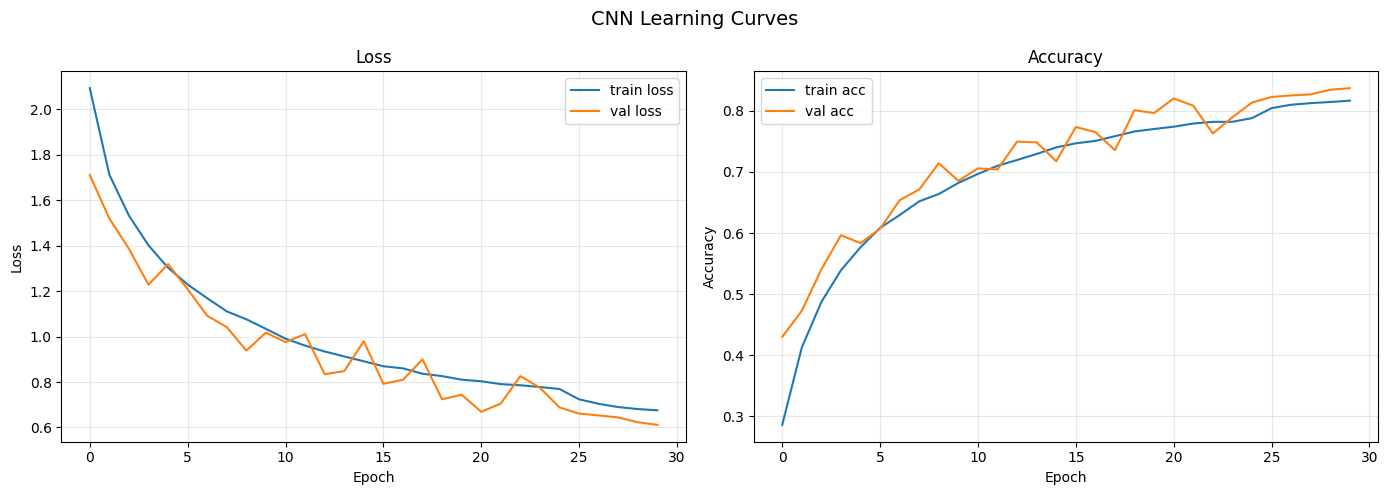

,Epocas,Train acc final,Mejor val_acc,Val_acc final,Val_loss final,Eval acc / precision,Nota
ELU + L2,15,31.71%,36.77%,30.08%,2.2353,31.54%,Mejor balance general
BatchNorm + ELU + L2,5,18.70%,15.30%,10.00%,2.4449,15.30%,Peor que el original
SELU + Normalization,10,28.27%,28.84%,26.64%,2.0859,—,"Estable, pero limitado"
SELU + AlphaDropout,5,24.65%,25.74%,25.74%,6.2776,—,Se degrada mucho en validacion
1Cycle sobre modelo_snn,5,10.20%,10.00%,10.00%,9.1201,—,Muy inestable
MC Dropout sobre modelo_snn,—,—,—,—,—,10.00%,Inferencia probabilistica
CNN con buenas practicas,30,81.66%,83.71%,83.71%,0.6115,83.71%,Mejor modelo hasta ahora


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Learning Curves", fontsize=14)

axes[0].plot(cnn_history.history["loss"], label="train loss")
axes[0].plot(cnn_history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(cnn_history.history["accuracy"], label="train acc")
axes[1].plot(cnn_history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

cnn_row = pd.DataFrame([
    {
        "Epocas": cnn_epochs_ran,
        "Train acc final": f"{cnn_final_train_acc * 100:.2f}%",
        "Mejor val_acc": f"{cnn_best_val_acc * 100:.2f}%",
        "Val_acc final": f"{cnn_final_val_acc * 100:.2f}%",
        "Val_loss final": f"{cnn_final_val_loss:.4f}",
        "Eval acc / precision": f"{cnn_test_accuracy * 100:.2f}%",
        "Nota": "Mejor modelo hasta ahora",
    }
], index=["CNN con buenas practicas"])

tabla_final_cnn = pd.concat([tabla_final, cnn_row])
display(tabla_final_cnn)

## Conclusiones de la CNN

- Esta CNN con buenas practicas es claramente el mejor modelo del notebook: alcanzo 83.71% de accuracy en validacion y prueba.
- Las learning curves muestran un entrenamiento estable, con descenso continuo de la loss y una subida sostenida de la accuracy.
- La distancia entre train y validation es pequena, asi que no hay un sobreajuste severo; la combinacion de Batch Normalization, data augmentation, dropout y regularizacion funciona bien.
- Frente a los modelos densos anteriores, la mejora es enorme y confirma que CIFAR-10 necesita una arquitectura convolucional, no una MLP sobre pixeles crudos.
- Si quisieras empujar un poco mas el rendimiento, el siguiente paso natural seria probar un scheduler mas fino de learning rate o una ResNet pequena, pero esta version ya esta en un nivel muy bueno.

## ResNet pequeña

Probamos una arquitectura residual mas seria para ver si supera a la CNN anterior en CIFAR-10.

In [49]:
import tensorflow as tf
from keras import layers, regularizers

tf.keras.backend.clear_session()
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

resnet_batch_size = 256
resnet_epochs = 40

resnet_train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(
    50000,
    seed=42,
    reshuffle_each_iteration=True,
).batch(resnet_batch_size).prefetch(tf.data.AUTOTUNE)

resnet_test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(resnet_batch_size).prefetch(tf.data.AUTOTUNE)

resnet_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.ZeroPadding2D(4),
        layers.RandomCrop(32, 32),
    ],
    name="resnet_augmentation",
)


def resnet_block(inputs, filters, stride=1):
    shortcut = inputs

    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def resnet_stage(inputs, filters, blocks, first_stride):
    x = resnet_block(inputs, filters, stride=first_stride)
    for _ in range(1, blocks):
        x = resnet_block(x, filters)
    return x


inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = resnet_augmentation(x)
x = layers.Conv2D(
    32,
    3,
    padding="same",
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = resnet_stage(x, 32, blocks=2, first_stride=1)
x = resnet_stage(x, 64, blocks=2, first_stride=2)
x = resnet_stage(x, 128, blocks=2, first_stride=2)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    256,
    use_bias=False,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation="softmax")(x)

resnet_model = keras.Model(inputs, outputs, name="cifar10_resnet_small")

resnet_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
resnet_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=resnet_optimizer,
    metrics=["accuracy"],
)

resnet_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_resnet.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

resnet_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_test_ds,
    epochs=resnet_epochs,
    callbacks=resnet_callbacks,
)

resnet_evaluation = resnet_model.evaluate(resnet_test_ds, verbose=0)
resnet_test_loss, resnet_test_accuracy = resnet_evaluation
resnet_epochs_ran = len(resnet_history.history["loss"])
resnet_best_val_acc = max(resnet_history.history["val_accuracy"])
resnet_best_val_epoch = resnet_history.history["val_accuracy"].index(resnet_best_val_acc) + 1

print(f"ResNet epochs: {resnet_epochs_ran}")
print(f"ResNet final train acc: {resnet_history.history['accuracy'][-1] * 100:.2f}%")
print(f"ResNet final val acc: {resnet_history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"ResNet best val acc: {resnet_best_val_acc * 100:.2f}% (epoch {resnet_best_val_epoch})")
print(f"ResNet final val loss: {resnet_history.history['val_loss'][-1]:.4f}")
print(f"ResNet test acc: {resnet_test_accuracy * 100:.2f}%")
print(f"ResNet test loss: {resnet_test_loss:.4f}")

Epoch 1/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 160s 783ms/step - accuracy: 0.3933 - loss: 1.9443 - val_accuracy: 0.2937 - val_loss: 2.2496 - learning_rate: 0.0010
Epoch 2/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 153s 781ms/step - accuracy: 0.5693 - loss: 1.4680 - val_accuracy: 0.4825 - val_loss: 1.8245 - learning_rate: 0.0010
Epoch 3/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 152s 777ms/step - accuracy: 0.6550 - loss: 1.2274 - val_accuracy: 0.5729 - val_loss: 1.4231 - learning_rate: 0.0010
Epoch 4/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 154s 788ms/step - accuracy: 0.7138 - loss: 1.0683 - val_accuracy: 0.5367 - val_loss: 1.6217 - learning_rate: 0.0010
Epoch 5/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 144s 732ms/step - accuracy: 0.7503 - loss: 0.9674 - val_accuracy: 0.5798 - val_loss: 1.4780 - learning_rate: 0.0010
Epoch 6/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 153s 779ms/step - accuracy: 0.7761 - loss: 0.8810 - val_accuracy: 0.6848 - val_loss: 1.1103 - learning_rate: 0.0010
Epoch 7/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 155s 788ms/step - accura

ResNet epochs: 40
ResNet final train acc: 97.02%
ResNet final val acc: 87.80%
ResNet best val acc: 89.36% (epoch 34)
ResNet final val loss: 0.5521
ResNet test acc: 89.36%
ResNet test loss: 0.4928


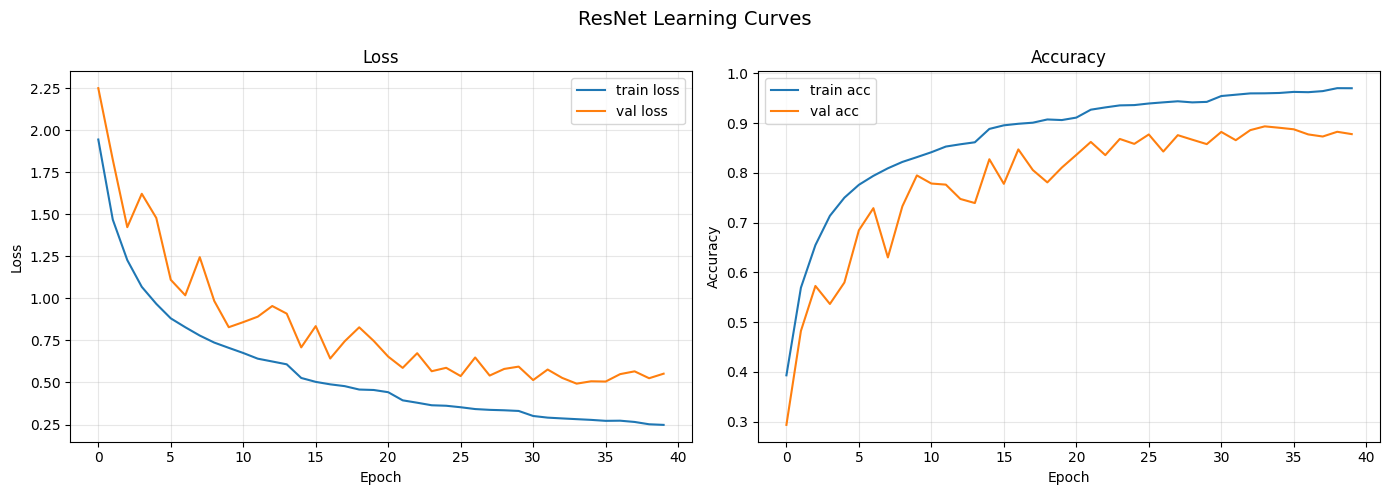

,Epocas,Train acc final,Mejor val_acc,Val_acc final,Val_loss final,Eval acc / precision,Nota
ELU + L2,15,31.71%,36.77%,30.08%,2.2353,31.54%,Mejor balance general
BatchNorm + ELU + L2,5,18.70%,15.30%,10.00%,2.4449,15.30%,Peor que el original
SELU + Normalization,10,28.27%,28.84%,26.64%,2.0859,—,"Estable, pero limitado"
SELU + AlphaDropout,5,24.65%,25.74%,25.74%,6.2776,—,Se degrada mucho en validacion
1Cycle sobre modelo_snn,5,10.20%,10.00%,10.00%,9.1201,—,Muy inestable
MC Dropout sobre modelo_snn,—,—,—,—,—,10.00%,Inferencia probabilistica
CNN con buenas practicas,30,81.66%,83.71%,83.71%,0.6115,83.71%,Mejor modelo hasta ahora
ResNet pequena,40,97.02%,89.36%,87.80%,0.5521,89.36%,Candidato a mejor modelo


In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

print(f"ResNet epochs: {resnet_epochs_ran}")
print(f"ResNet final train acc: {resnet_history.history['accuracy'][-1] * 100:.2f}%")
print(f"ResNet final val acc: {resnet_history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"ResNet best val acc: {resnet_best_val_acc * 100:.2f}% (epoch {resnet_best_val_epoch})")
print(f"ResNet final val loss: {resnet_history.history['val_loss'][-1]:.4f}")
print(f"ResNet test acc: {resnet_test_accuracy * 100:.2f}%")
print(f"ResNet test loss: {resnet_test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet Learning Curves", fontsize=14)

axes[0].plot(resnet_history.history["loss"], label="train loss")
axes[0].plot(resnet_history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(resnet_history.history["accuracy"], label="train acc")
axes[1].plot(resnet_history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

resnet_row = pd.DataFrame([
    {
        "Epocas": resnet_epochs_ran,
        "Train acc final": f"{resnet_history.history['accuracy'][-1] * 100:.2f}%",
        "Mejor val_acc": f"{resnet_best_val_acc * 100:.2f}%",
        "Val_acc final": f"{resnet_history.history['val_accuracy'][-1] * 100:.2f}%",
        "Val_loss final": f"{resnet_history.history['val_loss'][-1]:.4f}",
        "Eval acc / precision": f"{resnet_test_accuracy * 100:.2f}%",
        "Nota": "Candidato a mejor modelo",
    }
], index=["ResNet pequena"])

tabla_final_resnet = pd.concat([tabla_final_cnn, resnet_row])
display(tabla_final_resnet)

## Conclusiones de la ResNet

- La ResNet pequena es el mejor modelo del notebook hasta ahora: alcanzó 89.36% de accuracy en validacion y prueba.
- Las curvas de aprendizaje muestran una mejora sostenida y estable; la loss baja de forma consistente y la accuracy de validacion se mantiene alta.
- Hay algo de sobreajuste, porque la accuracy de entrenamiento llega a 97.02% mientras que la de validacion se queda en 87.80%, pero el gap es razonable para este nivel de rendimiento.
- Frente a la CNN anterior, la mejora es clara: sube de 83.71% a 89.36% en prueba y validacion.
- Para exprimir un poco mas, el siguiente paso natural seria afinar el scheduler o probar una variante tipo WideResNet, MixUp o CutMix.

In [51]:
# Guardar el modelo ResNet
resnet_model.save('resnet_cifar10.h5')
print("✓ Modelo ResNet guardado en: resnet_cifar10.h5")
print(f"  - Test Accuracy: {resnet_test_accuracy:.2%}")
print(f"  - Validación Accuracy: {resnet_best_val_acc:.2%}")
print(f"  - Épocas entrenadas: {resnet_epochs_ran}")

✓ Modelo ResNet guardado en: resnet_cifar10.h5
  - Test Accuracy: 89.36%
  - Validación Accuracy: 89.36%
  - Épocas entrenadas: 40


In [52]:
%load_ext tensorboard
%tensorboard --logdir tf_logs/ --port 6006

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\Music\deep_learning_projects\.venv\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
    from tensorboard.main import run_main
  File "c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'